C:\Users\milan\AppData\Local\Temp\ipykernel_27916\210147824.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ci_conf_l[i] = ci_l[i] - qhat
C:\Users\milan\AppData\Local\Temp\ipykernel_27916\210147824.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ci_conf_h[i] = ci_h[i] + qhat


CQR proper training conditional coverage:  0.94


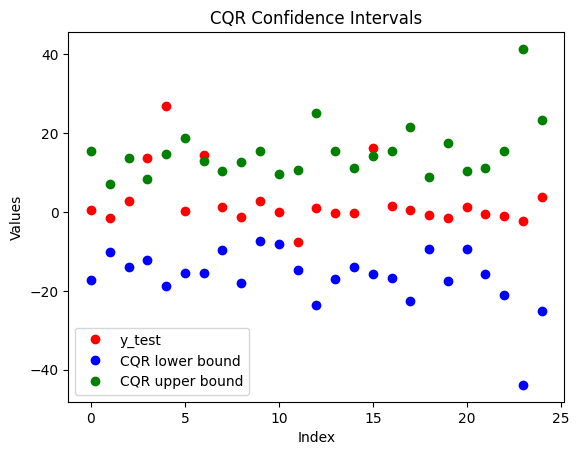

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as scs

def model(n, a0, a1, b):
    X = np.zeros((n, 3))
    y = np.zeros(n)
    for i in range(n):
        X[i, 0] = 2*scs.uniform.rvs() - 1
        X[i, 1] = 2*scs.uniform.rvs() - 1
        X[i, 2] = 1
        epsilon = scs.cauchy.rvs()
        y[i] = a0*X[i, 0] + a1*X[i, 1] + b + epsilon
    return X, y

X_reg, y_reg = model(500, 2, 1, 1)

X_test, y_test = model(200, 2, 1, 1)

#compute sigmahat2 and betahat - for multivariate linear regression

betahat = (np.linalg.inv(np.transpose(X_reg) @ X_reg) @ np.transpose(X_reg)) @ y_reg

y_reghat = X_reg @ betahat

sigmahat2 = np.sum((y_reg - y_reghat)*(y_reg - y_reghat))/(len(y_reg) - 3)

ypred = np.zeros(len(y_test))
ci_l = np.zeros(len(y_test))
ci_h = np.zeros(len(y_test))
ci_conf_l = np.zeros(len(y_test))
ci_conf_h = np.zeros(len(y_test))

S = 0

#compute the CQR scores for each element in X_conf and find the 0.975th quantile
for i in range(len(y_test)):
    X_conf, y_conf = model(200, 2, 1, 1)
    score = []
    for j in range(len(y_conf)):
        ytemp = np.transpose(X_conf[j]) @ betahat
        ci_l_temp = ytemp - scs.t.ppf(0.975, df = len(y_reg) - 3)*np.sqrt(sigmahat2*(1 + (np.transpose(X_conf[j]) @ np.linalg.inv(np.transpose(X_reg) @ X_reg)) @ X_conf[j]))
        ci_h_temp = ytemp + scs.t.ppf(0.975, df = len(y_reg) - 3)*np.sqrt(sigmahat2*(1 + (np.transpose(X_conf[j]) @ np.linalg.inv(np.transpose(X_reg) @ X_reg)) @ X_conf[j]))
        scorej = max(ci_l_temp - y_conf[j], y_conf[j] - ci_h_temp)
        score.append(scorej)

    sorted_scores = np.sort(score)
    qhat = scs.mstats.mquantiles(sorted_scores, 0.95*(1 + 1/len(y_conf)))

    #compute the confidence interval for each element in X_test and display the CQR confidence interval

    ypred[i] = np.transpose(X_test[i]) @ betahat
    ci_l[i] = ypred[i] - scs.t.ppf(0.975, df = len(y_reg) - 3)*np.sqrt(sigmahat2*(1 + (np.transpose(X_test[i]) @ np.linalg.inv(np.transpose(X_reg) @ X_reg)) @ X_test[i]))
    ci_h[i] = ypred[i] + scs.t.ppf(0.975, df = len(y_reg) - 3)*np.sqrt(sigmahat2*(1 + (np.transpose(X_test[i]) @ np.linalg.inv(np.transpose(X_reg) @ X_reg)) @ X_test[i]))
    ci_conf_l[i] = ci_l[i] - qhat
    ci_conf_h[i] = ci_h[i] + qhat

    if ci_conf_l[i] <= y_test[i] <= ci_conf_h[i]: S += 1

#plot the results
print("CQR proper training conditional coverage: ", S/len(y_test))

indices = np.arange(25)
plt.plot(indices, y_test[:25], 'ro', label='y_test')
plt.plot(indices, ci_conf_l[:25], 'bo', label='CQR lower bound')
plt.plot(indices, ci_conf_h[:25], 'go', label='CQR upper bound')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('CQR Confidence Intervals')
plt.show()